In [1]:
# Célula 1 — Imports e configuração de caminhos
# Importa todas as dependências e define os caminhos base do projeto
# usando Path().resolve().parent para funcionar independentemente
# de onde o notebook for aberto.

import pickle
import shutil
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

BASE_DIR    = Path().resolve().parent
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models'
FIGURES_DIR = BASE_DIR / 'figures'
TREC_DIR    = MODELS_DIR / 'trec'

DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
TREC_DIR.mkdir(exist_ok=True)

print(f'Projeto em  : {BASE_DIR}')
print(f'Dados em    : {DATA_DIR}')
print(f'Modelos em  : {TREC_DIR}')
print(f'Figuras em  : {FIGURES_DIR}')

/tmp/claude-1000/ipykernel_48846/1529231498.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto em  : /home/edson-luiz/Projetos/TCC
Dados em    : /home/edson-luiz/Projetos/TCC/data
Modelos em  : /home/edson-luiz/Projetos/TCC/models/trec
Figuras em  : /home/edson-luiz/Projetos/TCC/figures


In [2]:
# Célula 2 — Reorganização dos arquivos Enron para models/enron_original/
# Preserva os artefatos do treinamento anterior sem apagar nada.
# Verifica tanto a raiz de models/ quanto subpastas já existentes
# para evitar sobrescrever arquivos em execuções repetidas.

ENRON_DIR = MODELS_DIR / 'enron_original'
ENRON_DIR.mkdir(exist_ok=True)

# Arquivos candidatos a serem preservados
CANDIDATES = [
    'X_train_tfidf.pkl', 'X_test_tfidf.pkl',
    'y_train.pkl', 'y_test.pkl', 'tfidf.pkl',
    'model_naive_bayes.pkl', 'model_svm.pkl',
    'model_random_forest.pkl', 'model_regressao.pkl',
    'results.csv',
]

# Subpastas onde arquivos anteriores podem já ter sido movidos
LEGACY_DIRS = [MODELS_DIR / 'exp0_enron_original']

movidos = []
ja_existiam = []

for fname in CANDIDATES:
    dst = ENRON_DIR / fname

    # 1. Tenta mover da raiz de models/
    src_root = MODELS_DIR / fname
    if src_root.exists() and not dst.exists():
        shutil.copy2(str(src_root), str(dst))
        src_root.unlink()
        movidos.append(f'models/{fname} → enron_original/{fname}')
        continue

    # 2. Copia de subpastas legadas se ainda não estiver em enron_original/
    if not dst.exists():
        for legacy in LEGACY_DIRS:
            src_leg = legacy / fname
            if src_leg.exists():
                shutil.copy2(str(src_leg), str(dst))
                movidos.append(f'{legacy.name}/{fname} → enron_original/{fname}')
                break
    else:
        ja_existiam.append(fname)

print(f'Pasta criada: {ENRON_DIR}')
if movidos:
    print('\nArquivos preservados:')
    for m in movidos:
        print(f'  ✓ {m}')
if ja_existiam:
    print('\nJá existiam em enron_original/ (não sobrescritos):')
    for f in ja_existiam:
        print(f'  • {f}')
if not movidos and not ja_existiam:
    print('Nenhum arquivo Enron encontrado para mover.')

print('\nConteúdo de models/enron_original/:')
for p in sorted(ENRON_DIR.iterdir()):
    print(f'  {p.name}')

Pasta criada: /home/edson-luiz/Projetos/TCC/models/enron_original

Arquivos preservados:
  ✓ exp0_enron_original/X_train_tfidf.pkl → enron_original/X_train_tfidf.pkl
  ✓ exp0_enron_original/X_test_tfidf.pkl → enron_original/X_test_tfidf.pkl
  ✓ exp0_enron_original/y_train.pkl → enron_original/y_train.pkl
  ✓ exp0_enron_original/y_test.pkl → enron_original/y_test.pkl
  ✓ exp0_enron_original/tfidf.pkl → enron_original/tfidf.pkl
  ✓ exp0_enron_original/model_naive_bayes.pkl → enron_original/model_naive_bayes.pkl
  ✓ exp0_enron_original/model_svm.pkl → enron_original/model_svm.pkl
  ✓ exp0_enron_original/model_random_forest.pkl → enron_original/model_random_forest.pkl
  ✓ exp0_enron_original/model_regressao.pkl → enron_original/model_regressao.pkl
  ✓ exp0_enron_original/results.csv → enron_original/results.csv

Conteúdo de models/enron_original/:
  X_test_tfidf.pkl
  X_train_tfidf.pkl
  model_naive_bayes.pkl
  model_random_forest.pkl
  model_regressao.pkl
  model_svm.pkl
  results.csv
  t

In [3]:
# Célula 3 — Download e carregamento do dataset TREC 2007
# kagglehub baixa automaticamente e faz cache local.
# Se o CSV já existir em data/, o download é pulado.

TREC_CSV = DATA_DIR / 'trec_2007.csv'

if not TREC_CSV.exists():
    print('Baixando dataset via kagglehub...')
    kaggle_path = kagglehub.dataset_download(
        'imdeepmind/preprocessed-trec-2007-public-corpus-dataset'
    )
    print(f'Path do cache kagglehub: {kaggle_path}')

    # Localiza o CSV dentro da pasta baixada
    csv_files = list(Path(kaggle_path).rglob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'Nenhum CSV encontrado em {kaggle_path}')
    print(f'Arquivos CSV encontrados: {[f.name for f in csv_files]}')

    # Copia o maior CSV (mais provável de ser o dataset principal)
    src = max(csv_files, key=lambda f: f.stat().st_size)
    shutil.copy2(str(src), str(TREC_CSV))
    print(f'Copiado: {src.name} → {TREC_CSV}')
else:
    print(f'Dataset já existe: {TREC_CSV}')

df_raw = pd.read_csv(TREC_CSV, encoding='latin-1', on_bad_lines='skip')

print(f'\nShape: {df_raw.shape}')
print(f'Colunas: {df_raw.columns.tolist()}')
print(f'\nPrimeiras linhas:')
print(df_raw.head(3).to_string())

# Detecção automática das colunas de texto e rótulo
TEXT_CANDIDATES  = ['body', 'message', 'text', 'email', 'content', 'mail']
LABEL_CANDIDATES = ['label', 'spam', 'class', 'category', 'spam/ham', 'type', 'tag']

cols_lower = {c.lower(): c for c in df_raw.columns}

text_col  = next((cols_lower[c] for c in TEXT_CANDIDATES  if c in cols_lower), None)
label_col = next((cols_lower[c] for c in LABEL_CANDIDATES if c in cols_lower), None)

# Fallback: coluna de texto = maior coluna string; rótulo = menor cardinalidade
if text_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    text_col = max(str_cols, key=lambda c: df_raw[c].str.len().mean())

if label_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    label_col = min([c for c in str_cols if c != text_col],
                    key=lambda c: df_raw[c].nunique())

print(f'\nColuna de texto detectada : "{text_col}"')
print(f'Coluna de rótulo detectada: "{label_col}"')
print(f'\nDistribuição de classes:')
print(df_raw[label_col].value_counts())

Baixando dataset via kagglehub...


  0%|          | 0.00/167M [00:00<?, ?B/s]

  1%|          | 1.00M/167M [00:00<02:19, 1.25MB/s]

  1%|          | 2.00M/167M [00:01<01:13, 2.34MB/s]

  2%|▏         | 3.00M/167M [00:01<00:53, 3.21MB/s]

...

100%|██████████| 167M/167M [00:30<00:00, 5.78MB/s]

Extracting files...


Path do cache kagglehub: /home/edson-luiz/.cache/kagglehub/datasets/imdeepmind/preprocessed-trec-2007-public-corpus-dataset/versions/1
Arquivos CSV encontrados: ['processed_data.csv']


Copiado: processed_data.csv → /home/edson-luiz/Projetos/TCC/data/trec_2007.csv



Shape: (75419, 5)
Colunas: ['label', 'subject', 'email_to', 'email_from', 'message']

Primeiras linhas:
   label                            subject                         email_to                                            email_from                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            message
0      1 

In [4]:
# Célula 4 — Funções de pré-processamento
# truncate_to_150_words implementa o recorte deliberado de 150 palavras,
# variável central do estudo. preprocess aplica o pipeline NLP padrão.

STOP_WORDS = set(stopwords.words('english'))

def truncate_to_150_words(text):
    """Extrai as 150 primeiras palavras — recorte deliberado do estudo."""
    words = str(text).split()
    return ' '.join(words[:150])

def preprocess(text):
    """Lowercase → remove não-alfabéticos → tokeniza → remove stopwords."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def full_preprocess(text):
    return preprocess(truncate_to_150_words(text))

# Teste rápido
exemplo = 'Hello! This is a TEST email. Buy now: free offer limited time 100% guaranteed!!!'
print('Original  :', exemplo)
print('Truncado  :', truncate_to_150_words(exemplo))
print('Processado:', preprocess(truncate_to_150_words(exemplo)))

Original  : Hello! This is a TEST email. Buy now: free offer limited time 100% guaranteed!!!
Truncado  : Hello! This is a TEST email. Buy now: free offer limited time 100% guaranteed!!!
Processado: hello test email buy free offer limited time guaranteed


In [5]:
# Célula 5 — Aplicação do pré-processamento
# Aplica o pipeline completo sobre a coluna de texto detectada.
# Usamos a coluna original (text_col) definida na célula 3.

df = df_raw[[text_col, label_col]].copy()
df = df.dropna(subset=[text_col])

print(f'E-mails após remover nulos: {len(df)}')
print('Aplicando pré-processamento (pode levar alguns instantes)...')

df['text_processed'] = df[text_col].apply(full_preprocess)

# Comprimento em palavras após recorte e processamento
df['n_words'] = df['text_processed'].str.split().str.len()

# Comprimento antes do processamento (só truncagem)
df['n_words_truncated'] = df[text_col].apply(
    lambda x: len(truncate_to_150_words(x).split())
)

print(f'Concluído. Shape: {df.shape}')
print('\nExemplo:')
print(f'  Original  : {str(df[text_col].iloc[0])[:120]}...')
print(f'  Processado: {df["text_processed"].iloc[0][:120]}...')

E-mails após remover nulos: 73932
Aplicando pré-processamento (pode levar alguns instantes)...


Concluído. Shape: (73932, 5)

Exemplo:
  Original  : Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you feel the pressure to perform and not rising to the occas...
  Processado: contenttype texthtml contenttransferencoding bit feel pressure perform rising occasion try ia gr anxiety thing past back...


In [6]:
# Célula 6 — Remoção de vazios e mapeamento de rótulos
# Remove e-mails que ficaram sem conteúdo após o pré-processamento
# e converte os rótulos textuais para inteiros (spam=1, ham=0).

antes = len(df)
df = df[df['text_processed'].str.strip() != '']
depois = len(df)
print(f'Removidos {antes - depois} e-mails vazios após pré-processamento.')

# Detecção do padrão de rótulos e mapeamento para 0/1
valores_unicos = df[label_col].dropna().unique()
print(f'\nValores únicos na coluna de rótulo: {valores_unicos}')

# Tenta mapeamento direto por palavras-chave
label_map = {}
for v in valores_unicos:
    v_lower = str(v).strip().lower()
    if v_lower in ('spam', '1', 'yes', 'true', 's'):
        label_map[v] = 1
    elif v_lower in ('ham', '0', 'no', 'false', 'h', 'legitimate'):
        label_map[v] = 0

# Fallback: menor valor alfabético = ham (0)
if len(label_map) != len(valores_unicos):
    sorted_vals = sorted([str(v) for v in valores_unicos])
    label_map = {v: i for i, v in enumerate(sorted_vals)}
    print(f'Mapeamento por ordem alfabética: {label_map}')
else:
    print(f'Mapeamento aplicado: {label_map}')

df['label'] = df[label_col].map(label_map)
df = df[df['label'].notna()]
df['label'] = df['label'].astype(int)

print(f'\nCorpus final: {len(df)} e-mails')
print(df['label'].value_counts().rename({1: 'spam', 0: 'ham'}))

Removidos 158 e-mails vazios após pré-processamento.

Valores únicos na coluna de rótulo: [1 0]
Mapeamento aplicado: {1: 1, 0: 0}

Corpus final: 73774 e-mails
label
spam    48556
ham     25218
Name: count, dtype: int64


In [7]:
# Célula 7 — Estatísticas do corpus final
# Fornece uma visão quantitativa do corpus após todos os filtros,
# incluindo informações sobre a cobertura do recorte de 150 palavras.

total       = len(df)
n_spam      = (df['label'] == 1).sum()
n_ham       = (df['label'] == 0).sum()
pct_150     = (df['n_words_truncated'] >= 150).mean()

print('=' * 55)
print('ESTATÍSTICAS DO CORPUS FINAL — TREC 2007')
print('=' * 55)
print(f'Total de e-mails utilizáveis : {total:>8,}')
print(f'  Spam (1)                   : {n_spam:>8,}  ({n_spam/total:.1%})')
print(f'  Ham  (0)                   : {n_ham:>8,}  ({n_ham/total:.1%})')
print(f'\nE-mails com ≥ 150 palavras   : {pct_150:.1%}')
print(f'(para estes, o recorte é exato; para os demais, usa o texto integral)')
print('\nComprimento em palavras (após truncagem e processamento):')
print(df['n_words'].describe().round(1).to_string())
print('\nComprimento truncado bruto (antes do processamento NLP):')
print(df['n_words_truncated'].describe().round(1).to_string())
print('=' * 55)

ESTATÍSTICAS DO CORPUS FINAL — TREC 2007
Total de e-mails utilizáveis :   73,774
  Spam (1)                   :   48,556  (65.8%)
  Ham  (0)                   :   25,218  (34.2%)

E-mails com ≥ 150 palavras   : 59.6%
(para estes, o recorte é exato; para os demais, usa o texto integral)

Comprimento em palavras (após truncagem e processamento):


count    73774.0
mean        73.7
std         33.0
min          1.0
25%         52.0
50%         76.0
75%         91.0
max        150.0

Comprimento truncado bruto (antes do processamento NLP):
count    73774.0
mean       120.9
std         43.2
min          1.0
25%         91.0
50%        150.0
75%        150.0
max        150.0


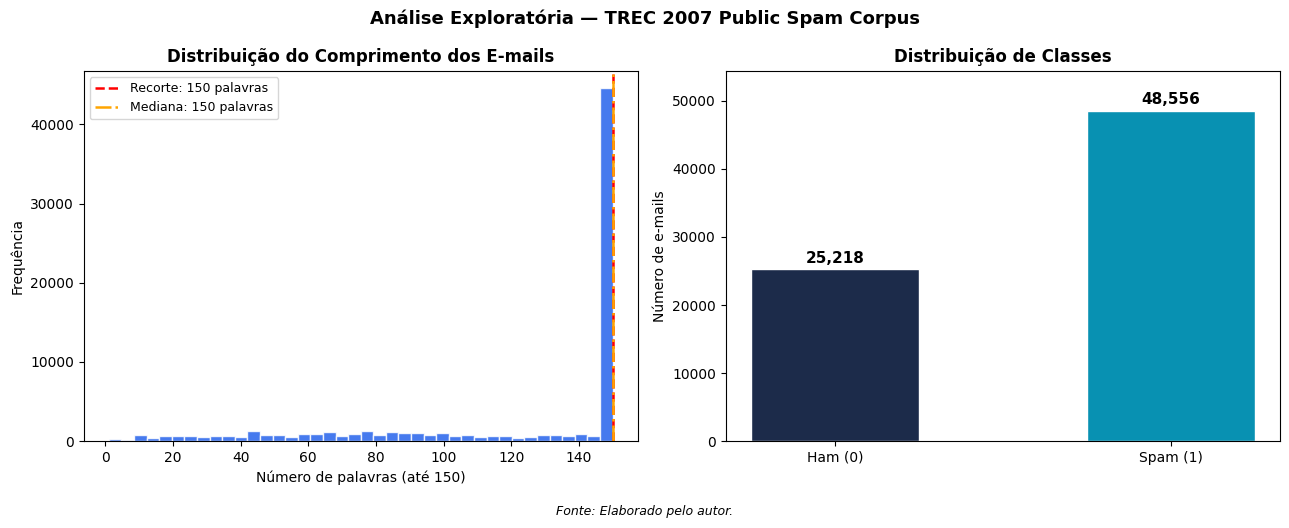

Figura salva: /home/edson-luiz/Projetos/TCC/figures/exploratory_analysis_trec.png


In [8]:
# Célula 8 — Análise exploratória e geração da figura
# Dois subplots: distribuição de comprimento dos e-mails
# e distribuição de classes. Linhas de referência em 150 palavras
# (recorte do estudo) e na mediana do corpus.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Análise Exploratória — TREC 2007 Public Spam Corpus',
    fontsize=13, fontweight='bold'
)

# --- Subplot 1: Histograma de comprimento ---
ax1 = axes[0]
comprimentos = df['n_words_truncated']
mediana = comprimentos.median()

ax1.hist(comprimentos, bins=40, color='#2563EB', edgecolor='white', alpha=0.85)
ax1.axvline(150,     color='red',    linewidth=1.8, linestyle='--',
            label=f'Recorte: 150 palavras')
ax1.axvline(mediana, color='orange', linewidth=1.8, linestyle='-.',
            label=f'Mediana: {mediana:.0f} palavras')
ax1.set_title('Distribuição do Comprimento dos E-mails', fontweight='bold')
ax1.set_xlabel('Número de palavras (até 150)')
ax1.set_ylabel('Frequência')
ax1.legend(fontsize=9)

# --- Subplot 2: Distribuição de classes ---
ax2 = axes[1]
contagens = df['label'].value_counts().sort_index()
rotulos   = ['Ham (0)', 'Spam (1)']
cores     = ['#1C2B4A', '#0891B2']

bars = ax2.bar(rotulos, contagens.values, color=cores, edgecolor='white', width=0.5)
for bar, val in zip(bars, contagens.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + contagens.max() * 0.01,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax2.set_title('Distribuição de Classes', fontweight='bold')
ax2.set_ylabel('Número de e-mails')
ax2.set_ylim(0, contagens.max() * 1.12)

fig.text(0.5, -0.03, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exploratory_analysis_trec.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura salva: {FIGURES_DIR / "exploratory_analysis_trec.png"}')

In [9]:
# Célula 9 — Split estratificado 80/20
# Stratify garante que a proporção spam/ham seja mantida
# igual em treino e teste, evitando viés de amostragem.

X = df['text_processed']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Treino : {len(X_train):,} e-mails')
print(f'Teste  : {len(X_test):,} e-mails')
print(f'\nProporção spam no treino: {y_train.mean():.2%}')
print(f'Proporção spam no teste : {y_test.mean():.2%}')

Treino : 59,019 e-mails
Teste  : 14,755 e-mails

Proporção spam no treino: 65.82%
Proporção spam no teste : 65.81%


In [10]:
# Célula 10 — Vetorização TF-IDF
# O TF-IDF é ajustado (fit) APENAS nos dados de treino para evitar
# data leakage. O conjunto de teste recebe apenas transform,
# simulando o comportamento real de inferência em produção.

tfidf = TfidfVectorizer(
    max_features=10000,
    sublinear_tf=True,   # aplica log(1 + tf) — reduz impacto de termos muito frequentes
    min_df=2,            # ignora termos raros (< 2 documentos)
    ngram_range=(1, 2)   # unigramas e bigramas
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform no treino
X_test_tfidf  = tfidf.transform(X_test)        # apenas transform no teste

print(f'Shape treino : {X_train_tfidf.shape}')
print(f'Shape teste  : {X_test_tfidf.shape}')
print(f'Vocabulário  : {len(tfidf.vocabulary_):,} termos')

print('\nTop 20 termos por TF-IDF médio no treino:')
scores  = X_train_tfidf.mean(axis=0).A1
top_idx = scores.argsort()[-20:][::-1]
vocab_inv = {v: k for k, v in tfidf.vocabulary_.items()}
for idx in top_idx:
    print(f'  {vocab_inv[idx]:<30} {scores[idx]:.4f}')

Shape treino : (59019, 10000)
Shape teste  : (14755, 10000)
Vocabulário  : 10,000 termos

Top 20 termos por TF-IDF médio no treino:
  contenttype                    0.0259
  contenttransferencoding        0.0234
  quotedprintable                0.0165
  contenttransferencoding quotedprintable 0.0165
  textplain                      0.0155
  contenttype textplain          0.0155
  texthtml                       0.0136
  email                          0.0135
  contenttype texthtml           0.0131
  charsetiso                     0.0129
  bit                            0.0125
  charsetiso contenttransferencoding 0.0121
  contenttransferencoding bit    0.0118
  wrote                          0.0114
  one                            0.0109
  like                           0.0108
  please                         0.0106
  get                            0.0105
  may                            0.0101
  new                            0.0100


In [11]:
# Célula 11 — Salvamento dos artefatos em models/trec/
# Persiste todos os objetos necessários para o treinamento e avaliação
# dos modelos no notebook seguinte, mantendo isolamento de experimentos.

artefatos = {
    'X_train_tfidf': X_train_tfidf,
    'X_test_tfidf':  X_test_tfidf,
    'y_train':       y_train,
    'y_test':        y_test,
    'tfidf':         tfidf,
}

for nome, obj in artefatos.items():
    caminho = TREC_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Salvo: {caminho}')

print('\n' + '=' * 55)
print('RESUMO — ARQUIVOS GERADOS')
print('=' * 55)
print(f'Figura  : {FIGURES_DIR / "exploratory_analysis_trec.png"}')
for nome in artefatos:
    print(f'Artefato: {TREC_DIR / (nome + ".pkl")}')
print('=' * 55)
print('\nPré-processamento TREC 2007 concluído.')
print('Execute o notebook de avaliação dos modelos para prosseguir.')

  Salvo: /home/edson-luiz/Projetos/TCC/models/trec/X_train_tfidf.pkl
  Salvo: /home/edson-luiz/Projetos/TCC/models/trec/X_test_tfidf.pkl
  Salvo: /home/edson-luiz/Projetos/TCC/models/trec/y_train.pkl
  Salvo: /home/edson-luiz/Projetos/TCC/models/trec/y_test.pkl


  Salvo: /home/edson-luiz/Projetos/TCC/models/trec/tfidf.pkl

RESUMO — ARQUIVOS GERADOS
Figura  : /home/edson-luiz/Projetos/TCC/figures/exploratory_analysis_trec.png
Artefato: /home/edson-luiz/Projetos/TCC/models/trec/X_train_tfidf.pkl
Artefato: /home/edson-luiz/Projetos/TCC/models/trec/X_test_tfidf.pkl
Artefato: /home/edson-luiz/Projetos/TCC/models/trec/y_train.pkl
Artefato: /home/edson-luiz/Projetos/TCC/models/trec/y_test.pkl
Artefato: /home/edson-luiz/Projetos/TCC/models/trec/tfidf.pkl

Pré-processamento TREC 2007 concluído.
Execute o notebook de avaliação dos modelos para prosseguir.
